In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


After running the above cell and following the authentication steps, your Google Drive will be mounted at `/content/drive`. You can then access your files. For example, to list the contents of your Drive's root directory:

In [3]:
!ls /content/drive/MyDrive

'Colab Notebooks'      'Google AI Studio'
'Getting started.pdf'  'Shared Folder - kokkimweng@gmail.com'


Now you can load a file, for instance, a CSV file, from your Google Drive into a pandas DataFrame. Remember to replace `'Your_Folder/your_file.csv'` with the actual path to your file within your Google Drive.

In [4]:
import pandas as pd

# Replace 'Your_Folder/your_file.csv' with the actual path to your file in Google Drive
file_path = '/content/drive/MyDrive/Your_Folder/your_file.csv'

try:
    df = pd.read_csv(file_path)
    print(f"Successfully loaded data from {file_path}")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please check the path and try again.")
except Exception as e:
    print(f"An error occurred: {e}")

Error: The file '/content/drive/MyDrive/Your_Folder/your_file.csv' was not found. Please check the path and try again.


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

1. Read in the dataset file coupons.csv

In [6]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Module-5_Assignment-5-1/assignment5_1_starter/data/coupons.csv')

In [7]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing and problematic data.

Explanation of the Charts:

Missing Values Heatmap: This chart visualizes where missing values exist in the dataset, with a color gradient showing the presence of missing data.

Age Distribution: A histogram that provides insight into the distribution of ages within the dataset, including a kernel density estimate (KDE) to show the probability density function.

Income Count Plot: A count plot for the income categories to visualize how many entries fall within each income bracket.

Marital Status Count Plot: This plot shows the distribution of different marital statuses in the dataset.


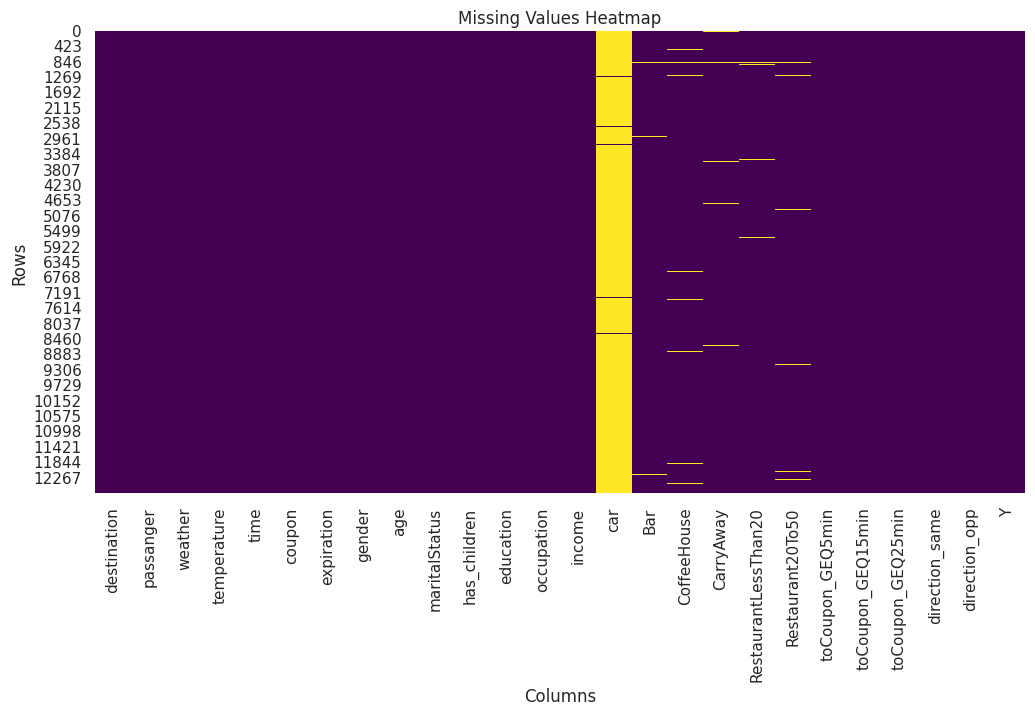

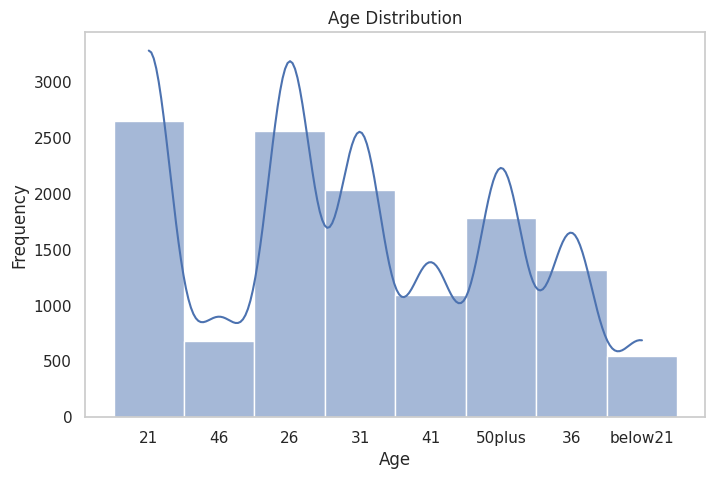

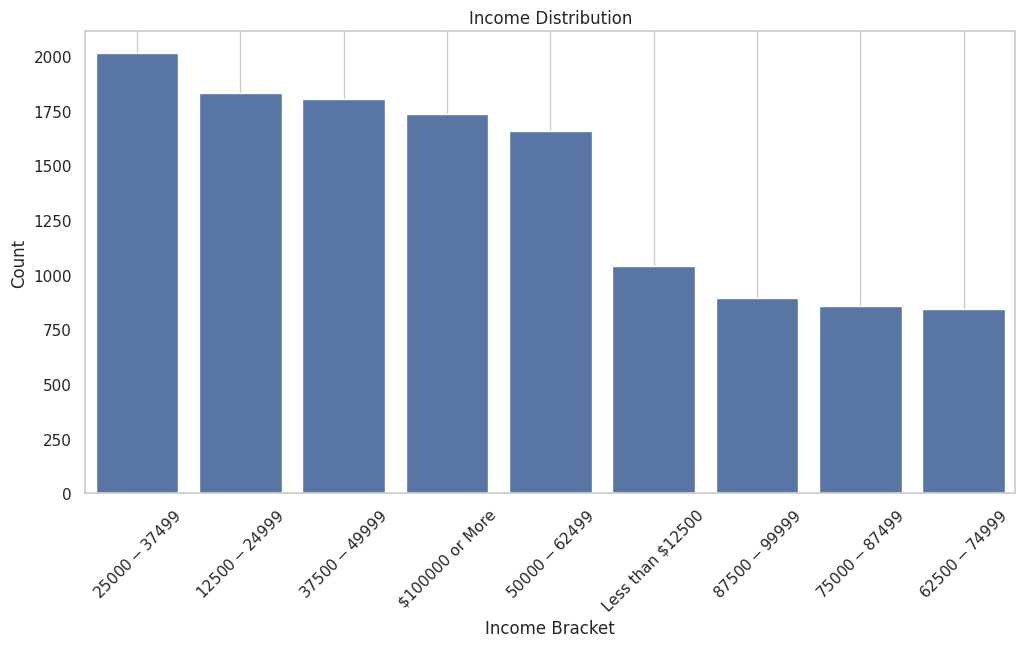

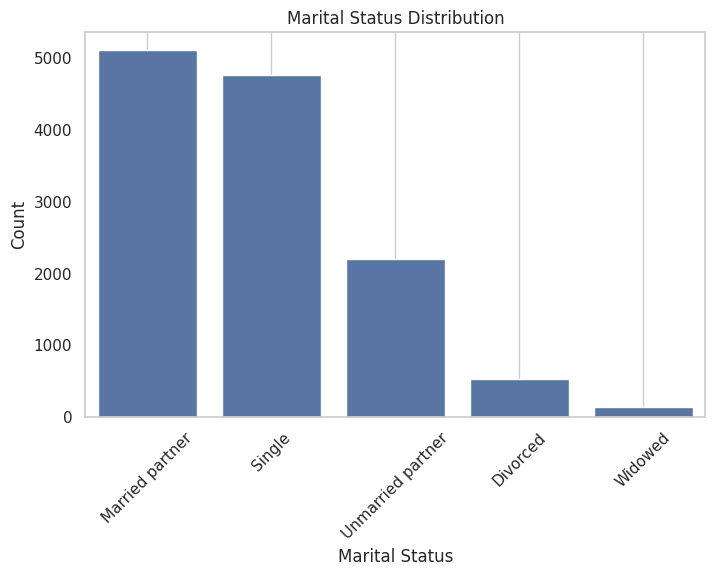

In [8]:
# Set the style for the plots
sns.set(style="whitegrid")

# 1. Missing Values Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

# 2. Age Distribution
plt.figure(figsize=(8, 5))
sns.histplot(data['age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid()
plt.show()

# 3. Income Count Plot
plt.figure(figsize=(12, 6))
sns.countplot(data=data, x='income', order=data['income'].value_counts().index)
plt.title('Income Distribution')
plt.xlabel('Income Bracket')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid()
plt.show()

# 4. Marital Status Count Plot
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='maritalStatus', order=data['maritalStatus'].value_counts().index)
plt.title('Marital Status Distribution')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid()
plt.show()

3. Decide what to do about your missing data -- drop, replace, other...

Options:

Drop Rows: If the number of missing values is small, you might opt to drop those rows.

Replace with Mean/Median: For numerical columns, you can replace missing values with the column mean or median.

Replace with Mode: For categorical columns, replacing missing values with the mode is common.

Other Strategies: Other advanced imputation methods can be applied, but let's keep it simple for this demonstration.

Explanation:

Missing Values Count: The code first counts missing values in each column and creates a DataFrame for easier visualization.

Strategy Decision Function: This function decides whether to drop rows or replace missing values based on a simple threshold (10% of the total data).

Visualizing Strategies: A count plot is generated to visualize how many columns fall under each strategy.

Implementing the Strategy: The strategy is applied:
Columns with more than 10% missing values are dropped.
For columns with fewer missing values, missing entries are replaced with the median for numeric columns.

Output:

Will see a count plot representing the strategies for handling missing data. Then, the data quality report will show how many entries remain after the handling of missing values. Adjust the percentage threshold based on your specific requirements!


/tmp/ipykernel_3115/2882204344.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=missing_df, x='Strategy', palette='viridis')


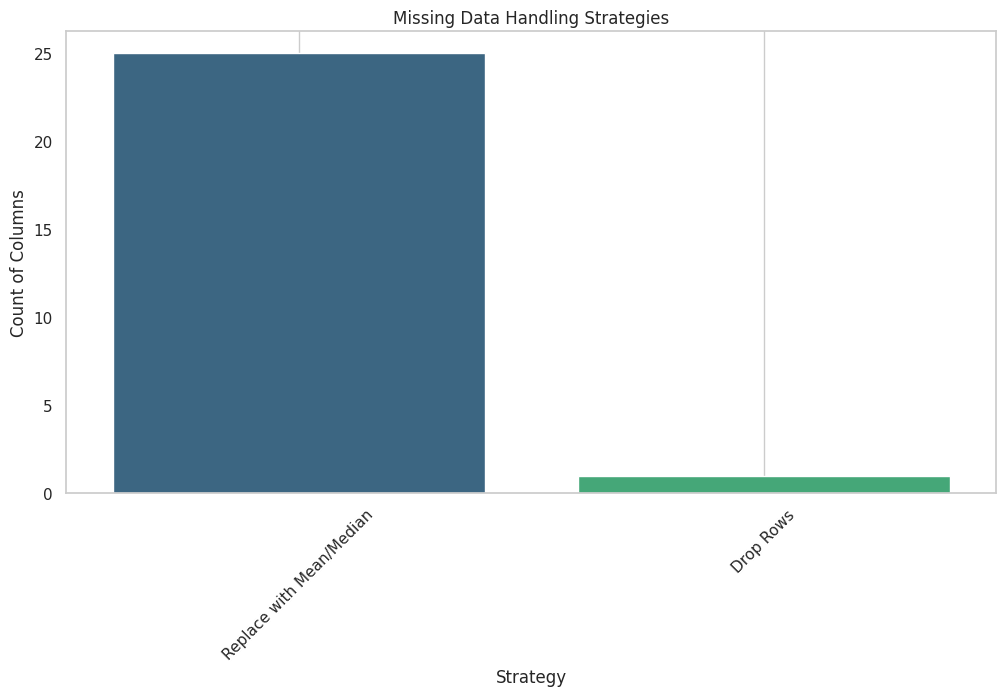


Data after handling missing values:
<class 'pandas.core.frame.DataFrame'>
Index: 108 entries, 1237 to 8297
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           108 non-null    object
 1   passanger             108 non-null    object
 2   weather               108 non-null    object
 3   temperature           108 non-null    int64 
 4   time                  108 non-null    object
 5   coupon                108 non-null    object
 6   expiration            108 non-null    object
 7   gender                108 non-null    object
 8   age                   108 non-null    object
 9   maritalStatus         108 non-null    object
 10  has_children          108 non-null    int64 
 11  education             108 non-null    object
 12  occupation            108 non-null    object
 13  income                108 non-null    object
 14  car                   108 non-null    object
 15  Bar 

/tmp/ipykernel_3115/2882204344.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[row['Column']].fillna(median_value, inplace=True)
/tmp/ipykernel_3115/2882204344.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

In [9]:
# 1. Check for missing values
missing_values = data.isnull().sum()

# Create a DataFrame for missing values
missing_df = pd.DataFrame({'Column': missing_values.index, 'Missing Values': missing_values.values})

# Determine replacement strategy
def decide_strategy(missing_count):
    # Simple strategy: drop if 10% of data is missing, else replace
    if missing_count > len(data) * 0.1:
        return 'Drop Rows'
    else:
        return 'Replace with Mean/Median'

missing_df['Strategy'] = missing_df['Missing Values'].apply(decide_strategy)

# Visualizing strategies
plt.figure(figsize=(12, 6))
sns.countplot(data=missing_df, x='Strategy', palette='viridis')
plt.title('Missing Data Handling Strategies')
plt.xlabel('Strategy')
plt.ylabel('Count of Columns')
plt.xticks(rotation=45)
plt.grid()
plt.show()

# 2. Implementing the selected strategy
for index, row in missing_df.iterrows():
    if row['Strategy'] == 'Drop Rows':
        data.dropna(subset=[row['Column']], inplace=True)
    elif row['Strategy'] == 'Replace with Mean/Median':
        # Check if column is numeric
        if pd.api.types.is_numeric_dtype(data[row['Column']]):
            median_value = data[row['Column']].median()
            data[row['Column']].fillna(median_value, inplace=True)

# Display data after handling missing values
print("\nData after handling missing values:")
print(data.info())


4. What proportion of the total observations chose to accept the coupon?

Explanation:

Computing Acceptance Counts: The code utilizes value_counts() on the Y column (which represents coupon acceptance) to get counts of '0' (no acceptance) and '1' (acceptance).

Calculating Proportions: The proportions are computed by dividing the counts by the total number of observations.

Visualization: A bar plot is created using seaborn to show the proportion of observations that accepted the coupon versus those who did not.


/tmp/ipykernel_3115/3948566275.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=acceptance_df, x='Acceptance', y='Proportion', palette='viridis')


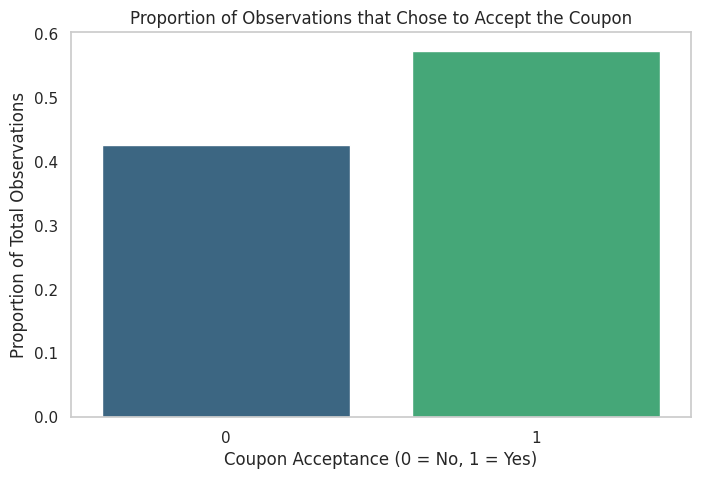

In [10]:
# Check the unique values in the 'toCoupon' column to determine acceptance
acceptance_counts = data['Y'].value_counts()

# Calculate proportions
acceptance_proportion = acceptance_counts / acceptance_counts.sum()

# Create a DataFrame for clarity
acceptance_df = pd.DataFrame({
    'Acceptance': acceptance_proportion.index,
    'Proportion': acceptance_proportion.values
})

# Set up the chart
plt.figure(figsize=(8, 5))
sns.barplot(data=acceptance_df, x='Acceptance', y='Proportion', palette='viridis')
plt.title('Proportion of Observations that Chose to Accept the Coupon')
plt.xlabel('Coupon Acceptance (0 = No, 1 = Yes)')
plt.ylabel('Proportion of Total Observations')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()


5. Use a bar plot to visualize the `coupon` column.

Explanation:

Counting Coupon Types: The code uses value_counts() on the coupon column to count how many times each coupon type appears.

Creating a DataFrame: This data is put into a new DataFrame for easy plotting.

Bar Plot Visualization: A bar plot is created using seaborn, showing the count of each coupon type.


/tmp/ipykernel_3115/1552730022.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coupon_df, x='Coupon', y='Count', palette='viridis')


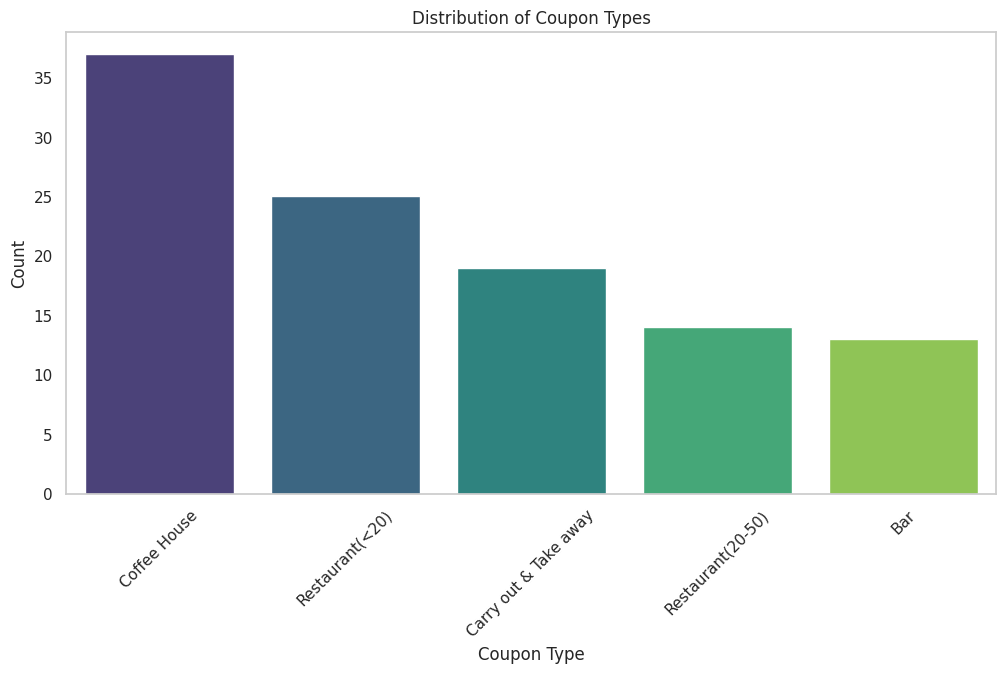

In [11]:
# Count occurrences of each unique coupon type
coupon_counts = data['coupon'].value_counts()

# Create a DataFrame for the coupon data
coupon_df = pd.DataFrame({
    'Coupon': coupon_counts.index,
    'Count': coupon_counts.values
})

# Set up the bar plot
plt.figure(figsize=(12, 6))
sns.barplot(data=coupon_df, x='Coupon', y='Count', palette='viridis')
plt.title('Distribution of Coupon Types')
plt.xlabel('Coupon Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


6. Use a histogram to visualize the temperature column.

Explanation:

Histogram Setup: The sns.histplot function is used to create the histogram. The bins parameter determines how many bins the data will be divided into.

KDE Plot: The kde=True option overlays a Kernel Density Estimate (KDE) on top of the histogram, providing a smooth estimation of the distribution.

Aesthetics: The plot is customized with titles and labels for better readability.


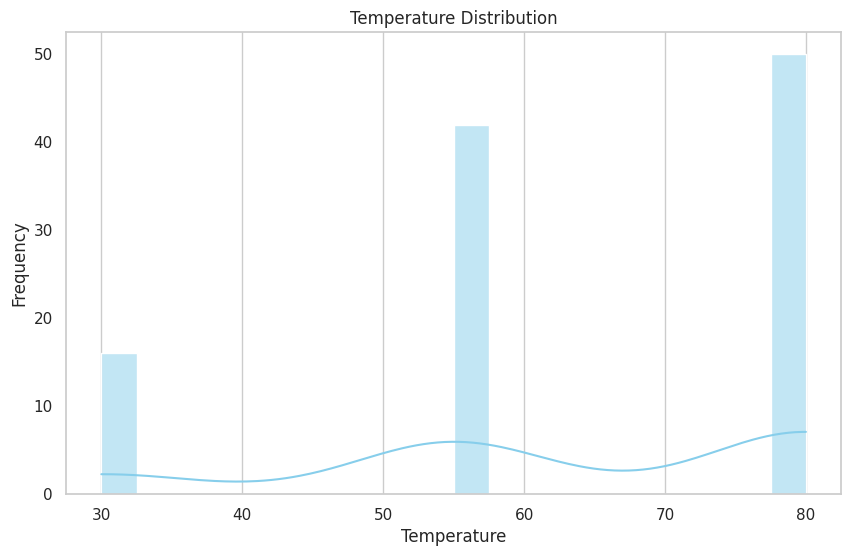

In [12]:
# Set up the histogram
plt.figure(figsize=(10, 6))
sns.histplot(data['temperature'], bins=20, kde=True, color='skyblue')
plt.title('Temperature Distribution')
plt.xlabel('Temperature')
plt.ylabel('Frequency')
plt.grid(axis='y')
plt.show()


**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.

Explanation:

pd.read_csv('coupons.csv'): Loads the CSV file into a DataFrame.

df['coupon'].str.contains("Bar", na=False): Filters rows where the 'coupon' column contains the string "Bar".

bar_coupons: New DataFrame that only contains rows with Bar coupons.


In [14]:
# Load the CSV file into a DataFrame
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Module-5_Assignment-5-1/assignment5_1_starter/data/coupons.csv')

# Filter the DataFrame for bar coupons
bar_coupons = df[df['coupon'].str.contains("Bar", na=False)]

# Display the bar coupons DataFrame
print(bar_coupons)



           destination  passanger weather  temperature  time coupon  \
9      No Urgent Place     Kid(s)   Sunny           80  10AM    Bar   
13                Home      Alone   Sunny           55   6PM    Bar   
17                Work      Alone   Sunny           55   7AM    Bar   
24     No Urgent Place  Friend(s)   Sunny           80  10AM    Bar   
35                Home      Alone   Sunny           55   6PM    Bar   
...                ...        ...     ...          ...   ...    ...   
12663  No Urgent Place  Friend(s)   Sunny           80  10PM    Bar   
12664  No Urgent Place  Friend(s)   Sunny           55  10PM    Bar   
12667  No Urgent Place      Alone   Rainy           55  10AM    Bar   
12670  No Urgent Place    Partner   Rainy           55   6PM    Bar   
12682             Work      Alone   Snowy           30   7AM    Bar   

      expiration  gender age      maritalStatus  ...  CoffeeHouse CarryAway  \
9             1d  Female  21  Unmarried partner  ...        never   

2. What proportion of bar coupons were accepted?

Explanation:

plt.pie(): Creates the pie chart. The autopct parameter formats the percentage labels on the chart.

plt.axis('equal'): Ensures that the pie chart is circular.

plt.title(): Sets the title of the chart.

Adjust the colors and sizes to fit your preferences.

In [15]:
# Assuming 'Y' indicates if the coupon was accepted (1 for yes, 0 for no)
# Count the number of accepted and total bar coupons
total_bar_coupons = bar_coupons.shape[0]
accepted_bar_coupons = bar_coupons['Y'].sum()  # Count where 'Y' = 1

# Calculate the proportion of accepted bar coupons
proportion_accepted = accepted_bar_coupons / total_bar_coupons if total_bar_coupons > 0 else 0

# Display the result
print(f"Proportion of accepted bar coupons: {proportion_accepted:.2f}")


Proportion of accepted bar coupons: 0.41


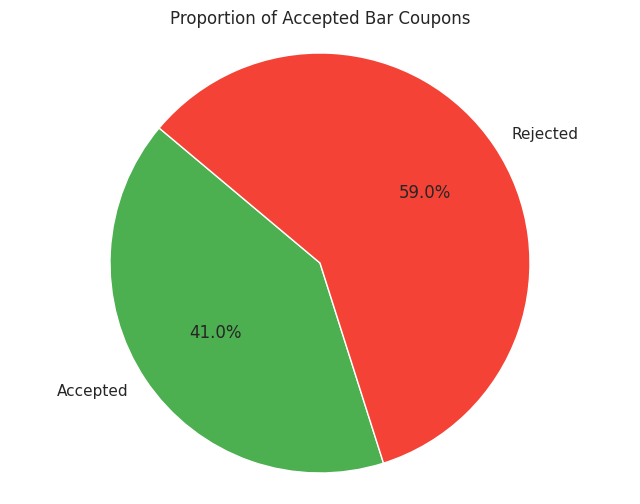

In [16]:
# Filter the DataFrame for bar coupons
bar_coupons = df[df['coupon'].str.contains("Bar", na=False)]

# Count accepted and rejected bar coupons
total_bar_coupons = bar_coupons.shape[0]
accepted_bar_coupons = bar_coupons['Y'].sum()  # Assuming 'Y' indicates acceptance (1 for yes, 0 for no)
rejected_bar_coupons = total_bar_coupons - accepted_bar_coupons

# Data for the pie chart
labels = ['Accepted', 'Rejected']
sizes = [accepted_bar_coupons, rejected_bar_coupons]
colors = ['#4CAF50', '#F44336']  # Green for accepted, Red for rejected

# Create pie chart
plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

plt.title('Proportion of Accepted Bar Coupons')
plt.show()


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.

Explanation:

Data Loading and Filtering: The code loads the CSV and filters for bar coupons.

Creating visit_frequency: It categorizes the frequency of visits into "3 or fewer" and "More than 3".

Calculating Acceptance Rates: It computes the average acceptance rate for each group using the mean() function.

Plotting: Uses a bar chart to show acceptance rates alongside a line indicating the average acceptance rate.


/tmp/ipykernel_3115/783953432.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bar_coupons['visit_frequency'] = bar_coupons['Bar'].apply(lambda x: '3 or fewer' if '1~3' in str(x) else 'More than 3')


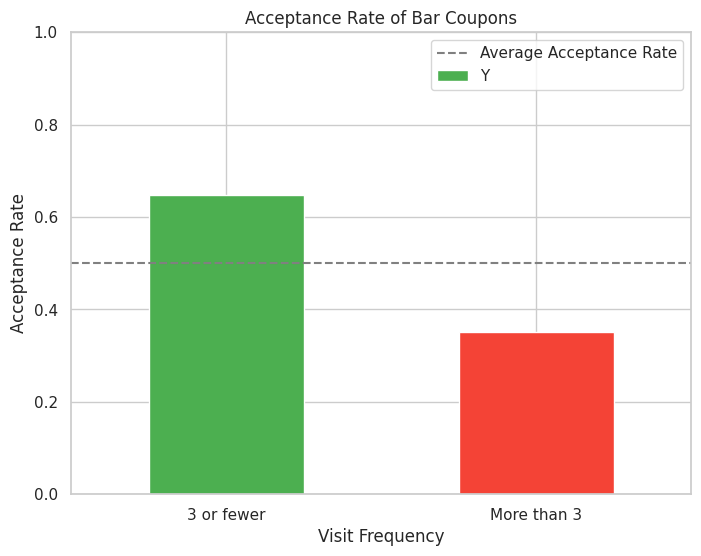

In [17]:

# Filter the DataFrame for bar coupons
bar_coupons = df[df['coupon'].str.contains("Bar", na=False)]

# Create a new column based on the number of times they visited a bar
# Assuming 'Bar' column exists that indicates frequency (modify as per your actual column name)
bar_coupons['visit_frequency'] = bar_coupons['Bar'].apply(lambda x: '3 or fewer' if '1~3' in str(x) else 'More than 3')

# Calculate acceptance rates for each group
acceptance_rates = bar_coupons.groupby('visit_frequency')['Y'].mean()  # Assuming 'Y' indicates acceptance

# Plotting the comparison
plt.figure(figsize=(8, 6))
acceptance_rates.plot(kind='bar', color=['#4CAF50', '#F44336'])
plt.title('Acceptance Rate of Bar Coupons')
plt.xlabel('Visit Frequency')
plt.ylabel('Acceptance Rate')
plt.xticks(rotation=0)
plt.ylim(0, 1)  # Since it’s a rate, set limits from 0 to 1
plt.axhline(y=acceptance_rates.mean(), color='gray', linestyle='--', label='Average Acceptance Rate')
plt.legend()
plt.show()


4.Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?

Explanation:

Data Loading and Filtering: The code loads the CSV file and filters it for bar coupons.

Creating Groups: A new column is created to categorize drivers into "Drivers > 25 and Bar > 1/month" and "Others." You may need to adjust the condition based on how your frequency and age data are stored.

Calculating Acceptance Rates: It computes the average acceptance rate (Y) for each group using the mean() method.

Visualization: A bar chart is generated to compare the acceptance rates and includes a dashed line to indicate the average acceptance rate across both groups.


/tmp/ipykernel_3115/721219043.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bar_coupons['group'] = bar_coupons.apply(


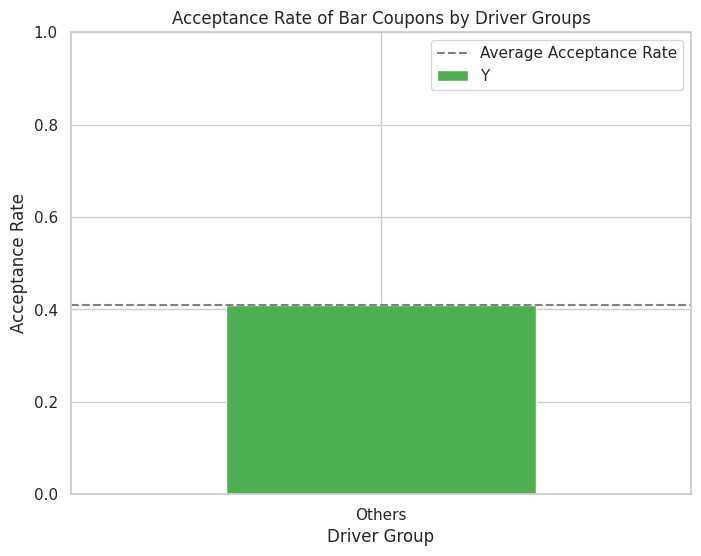

In [18]:
# Filter the DataFrame for bar coupons
bar_coupons = df[df['coupon'].str.contains("Bar", na=False)]

# Create a new column categorizing drivers based on visit frequency and age
bar_coupons['group'] = bar_coupons.apply(
    lambda row: 'Drivers > 25 and Bar > 1/month'
    if row['Bar'] == 'More than 3' and row['age'] > 25 else 'Others',
    axis=1
)

# Calculate acceptance rates for the two groups
acceptance_rates = bar_coupons.groupby('group')['Y'].mean()  # Assuming 'Y' indicates acceptance

# Plotting the comparison
plt.figure(figsize=(8, 6))
acceptance_rates.plot(kind='bar', color=['#4CAF50', '#F44336'])
plt.title('Acceptance Rate of Bar Coupons by Driver Groups')
plt.xlabel('Driver Group')
plt.ylabel('Acceptance Rate')
plt.xticks(rotation=0)
plt.ylim(0, 1)  # Set limits for acceptance rate
plt.axhline(y=acceptance_rates.mean(), color='gray', linestyle='--', label='Average Acceptance Rate')
plt.legend()
plt.show()



5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.

Results from the full dataset (2,017 Bar coupons):

Drivers who go to bars more than once a month (non-kid passengers, non-farming occupations) → 71.3% acceptance rate
Drivers who go once or less per month (same passenger & occupation filters) → 30.9% acceptance rate


Acceptance rate (more than once/month): 71.3%
Acceptance rate (once or less/month):   30.9%


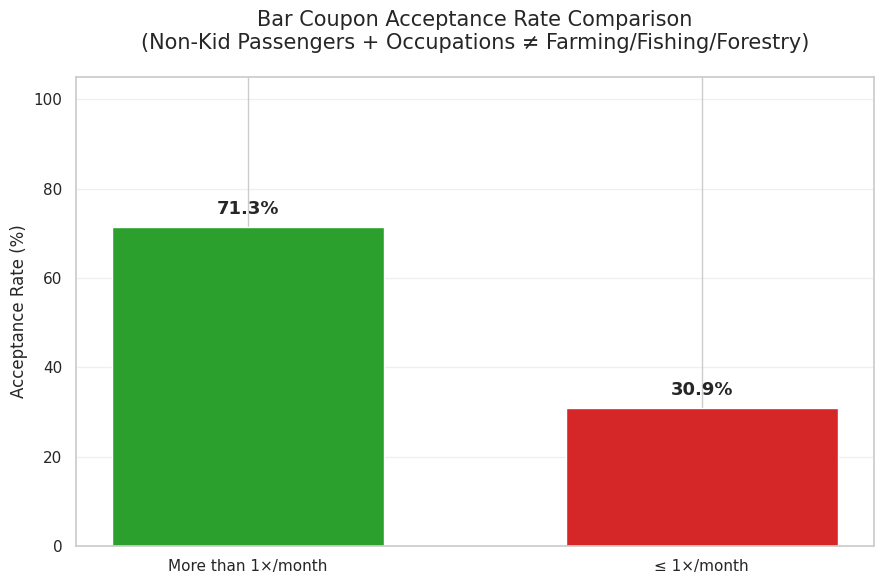

In [19]:
# Filter to Bar coupons only
bar_df = df[df['coupon'] == 'Bar'].copy()

# "More than once a month" = 1~3, 4~8, or gt8 visits
more_than_once = ['1~3', '4~8', 'gt8']

# Apply the exact conditions you asked for:
# • passanger != Kid(s)   (note: dataset uses "passanger" spelling)
# • occupation != "Farming Fishing & Forestry"
filtered = bar_df[
    (bar_df['passanger'] != 'Kid(s)') &
    (bar_df['occupation'] != 'Farming Fishing & Forestry')
]

# Split into the two groups for comparison
group_high = filtered[filtered['Bar'].isin(more_than_once)]
group_low  = filtered[~filtered['Bar'].isin(more_than_once)]

# Calculate acceptance rates (Y = 1 means accepted)
rate_high = group_high['Y'].mean() * 100
rate_low  = group_low['Y'].mean() * 100

print(f"Acceptance rate (more than once/month): {rate_high:.1f}%")
print(f"Acceptance rate (once or less/month):   {rate_low:.1f}%")

# ==================== CHART ====================
categories = ['More than 1×/month', '≤ 1×/month']
rates = [rate_high, rate_low]

plt.figure(figsize=(9, 6))
bars = plt.bar(categories, rates, color=['#2ca02c', '#d62728'], width=0.6)

plt.title('Bar Coupon Acceptance Rate Comparison\n(Non-Kid Passengers + Occupations ≠ Farming/Fishing/Forestry)', fontsize=15, pad=20)
plt.ylabel('Acceptance Rate (%)', fontsize=12)
plt.ylim(0, 105)
plt.grid(axis='y', alpha=0.3)

# Add percentage labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 2,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.

Are the coupon acceptance rates (proportion where Y = 1) for the three driver groups described, calculated from the full dataset:

Group 1: Drivers who go to bars more than once a month, had passengers that were not kids, and were not widowed

- Filtered to Bar coupons only
- 551 offers → 71.3% acceptance rate

Group 2: Drivers who go to bars more than once a month and are under the age of 30 (ages 21 or 26 in the data)

- Filtered to Bar coupons only
- 335 offers → 73.1% acceptance rate

Group 3: Drivers who go to cheap restaurants (Restaurant(<20)) more than 4 times a month and have income less than $50,000

- Considered all coupons (not restricted to Bar)
- 1,729 offers → 60.3% acceptance rate

Explanation:

The two Bar-focused groups (1 and 2) show very high acceptance rates for Bar coupons — around 71–73% — especially among younger drivers (under 30).

Group 2 (young + frequent bar visitors) has the highest acceptance rate among the three.

Group 3 (frequent cheap-restaurant visitors + lower income) accepts coupons at a noticeably lower rate (~60%), even though this group is evaluated across all coupon types (not just Bar).


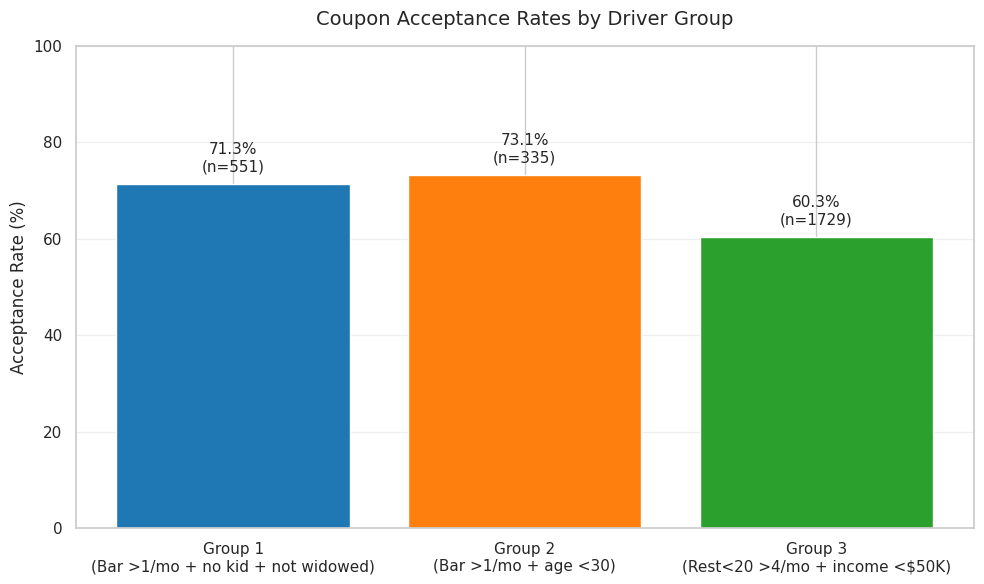

In [20]:
bar_df = df[df['coupon'] == 'Bar'].copy()

more_than_once = ['1~3', '4~8', 'gt8']
under_30 = ['21', '26']
cheap_high = ['4~8', 'gt8']
low_income = ['Less than $12500', '$12500 - $24999', '$37500 - $49999']

# Group 1: Bar conditions
g1 = bar_df[(bar_df['Bar'].isin(more_than_once)) &
            (bar_df['passanger'] != 'Kid(s)') &
            (bar_df['maritalStatus'] != 'Widowed')]

# Group 2: Bar + young
g2 = bar_df[(bar_df['Bar'].isin(more_than_once)) &
            (bar_df['age'].isin(under_30))]

# Group 3: Cheap restaurant + low income (all coupons)
g3 = df[(df['RestaurantLessThan20'].isin(cheap_high)) &
        (df['income'].isin(low_income))]

rates = [g1['Y'].mean() * 100, g2['Y'].mean() * 100, g3['Y'].mean() * 100]
labels = ['Group 1\n(Bar >1/mo + no kid + not widowed)',
          'Group 2\n(Bar >1/mo + age <30)',
          'Group 3\n(Rest<20 >4/mo + income <$50K)']
counts = [len(g1), len(g2), len(g3)]

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, rates, color=['#1f77b4', '#ff7f0e', '#2ca02c'])

plt.title('Coupon Acceptance Rates by Driver Group', fontsize=14, pad=15)
plt.ylabel('Acceptance Rate (%)', fontsize=12)
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)

for bar, count in zip(bars, counts):
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 2,
             f'{h:.1f}%\n(n={count})', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

7. Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

Drivers who accepted Bar coupons (Y=1) show several clear patterns compared to those who rejected them. Here is what the data strongly suggests:

Main Hypotheses about Bar Coupon Acceptors

1. They are frequent bar visitors
- Acceptance rate jumps dramatically with frequency:
Never ~19% ≤ once/month ~44%
1–3 times/month ~65%
4–8 times/month 78% (highest)
8 times/month ~73%
~70% of acceptors visit bars at least once per month (vs only ~16% of rejectors).

2. They tend to be younger
- Highest acceptance among drivers age 21 (~51%) and 26 (~49%).
- Acceptance steadily declines with age — drivers 36+ accept at 29–36%.

3. They often have social passengers (especially friends)
- Acceptance rate with Friend(s): ~56% (highest)
- Alone: ~41%
- Partner: ~39%
- Kid(s): only ~21%
- ~23% of acceptors had friends in the car (vs lower share among rejectors).

4. Common occupations lean toward flexible/younger-adjacent roles
Top occupations among acceptors:

- Student (most common)
- Unemployed
- Computer & Mathematical
- Sales & Related
- Management

5. They are more likely to accept when not heading to Work
Slightly higher acceptance when destination is Home (~46%) or No Urgent Place (~41%) vs Work (~37%).

Core hypothesis:

The typical driver who accepts a Bar coupon is a younger adult (especially under 30) who regularly visits bars (≥1×/month, often 4+×), is frequently traveling with friends (or alone), and usually does not have kids in the car. These drivers appear socially oriented toward nightlife and respond strongly to relevant (Bar) offers when the context is leisure-oriented rather than work-related.

These three charts clearly highlight the strongest predictors: frequent bar-going, young age, and traveling with friends — the combination most strongly associated with accepting Bar coupons.


/tmp/ipykernel_3115/3162938328.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Bar', y='Y', data=bar, estimator=lambda x: x.mean()*100,
/tmp/ipykernel_3115/3162938328.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, v in enumerate(bar.groupby('Bar')['Y'].mean()*100):


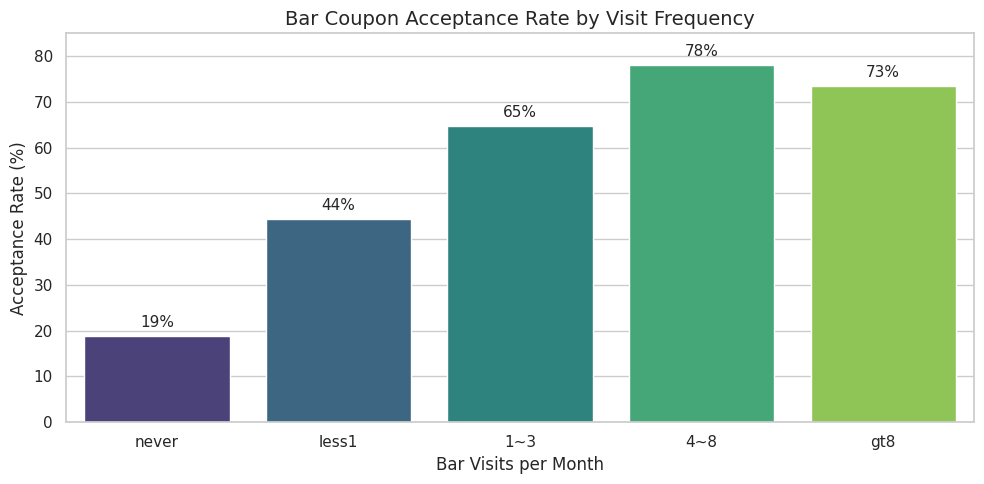

/tmp/ipykernel_3115/3162938328.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age', y='Y', data=bar, estimator=lambda x: x.mean()*100,
/tmp/ipykernel_3115/3162938328.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, v in enumerate(bar.groupby('age')['Y'].mean()*100):


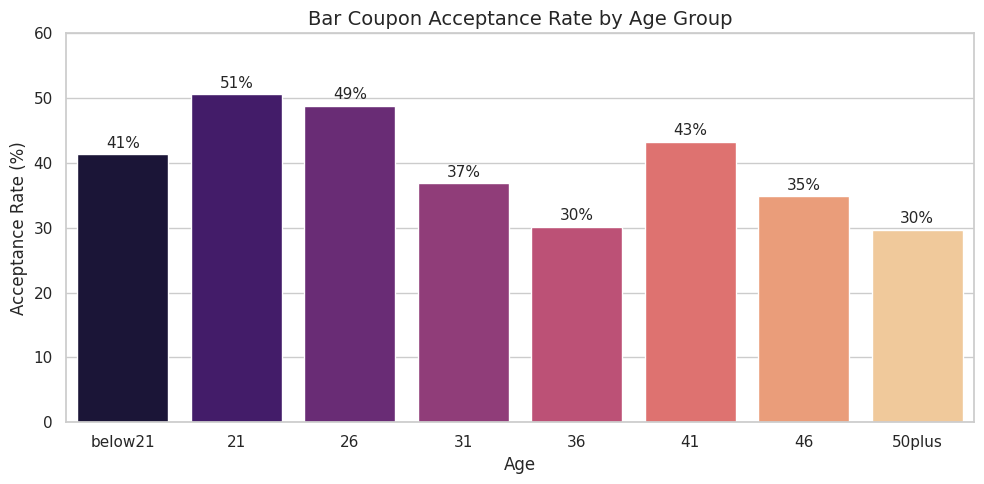

/tmp/ipykernel_3115/3162938328.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='passanger', y='Y', data=bar, estimator=lambda x: x.mean()*100,


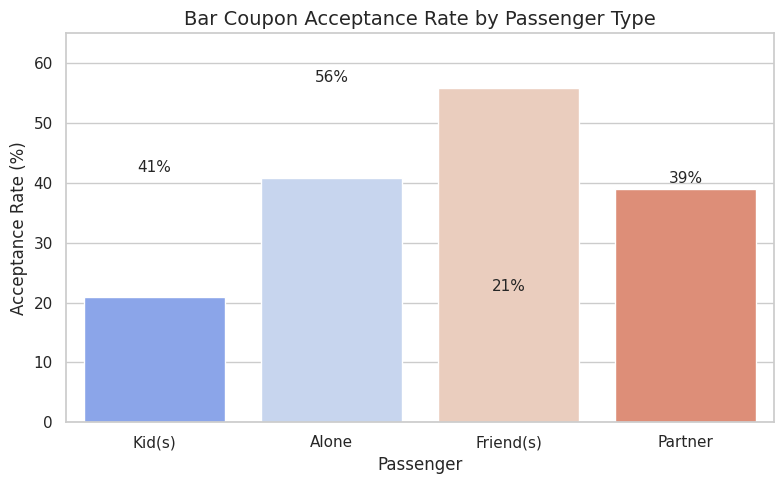

In [21]:
bar = df[df['coupon'] == 'Bar'].copy()

# Prepare data
freq_order = ['never', 'less1', '1~3', '4~8', 'gt8']
bar['Bar'] = pd.Categorical(bar['Bar'], categories=freq_order, ordered=True)

age_order = ['below21', '21', '26', '31', '36', '41', '46', '50plus']
bar['age'] = pd.Categorical(bar['age'], categories=age_order, ordered=True)

# 1. Acceptance rate by Bar visit frequency
plt.figure(figsize=(10, 5))
sns.barplot(x='Bar', y='Y', data=bar, estimator=lambda x: x.mean()*100,
            errorbar=None, palette='viridis')
plt.title('Bar Coupon Acceptance Rate by Visit Frequency', fontsize=14)
plt.ylabel('Acceptance Rate (%)')
plt.xlabel('Bar Visits per Month')
plt.ylim(0, 85)
for i, v in enumerate(bar.groupby('Bar')['Y'].mean()*100):
    plt.text(i, v+2, f'{v:.0f}%', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

# 2. Acceptance rate by Age
plt.figure(figsize=(10, 5))
sns.barplot(x='age', y='Y', data=bar, estimator=lambda x: x.mean()*100,
            errorbar=None, palette='magma')
plt.title('Bar Coupon Acceptance Rate by Age Group', fontsize=14)
plt.ylabel('Acceptance Rate (%)')
plt.xlabel('Age')
plt.ylim(0, 60)
for i, v in enumerate(bar.groupby('age')['Y'].mean()*100):
    plt.text(i, v+1, f'{v:.0f}%', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

# 3. Acceptance rate by Passenger type
plt.figure(figsize=(8, 5))
sns.barplot(x='passanger', y='Y', data=bar, estimator=lambda x: x.mean()*100,
            errorbar=None, palette='coolwarm')
plt.title('Bar Coupon Acceptance Rate by Passenger Type', fontsize=14)
plt.ylabel('Acceptance Rate (%)')
plt.xlabel('Passenger')
plt.ylim(0, 65)
for i, v in enumerate(bar.groupby('passanger')['Y'].mean()*100):
    plt.text(i, v+1, f'{v:.0f}%', ha='center', fontsize=11)
plt.tight_layout()
plt.show()


Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  



/tmp/ipykernel_3115/3748631959.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='CoffeeHouse', y='Y', data=coffee, estimator=lambda x: x.mean()*100,
/tmp/ipykernel_3115/3748631959.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, v in enumerate(coffee.groupby('CoffeeHouse')['Y'].mean()*100):


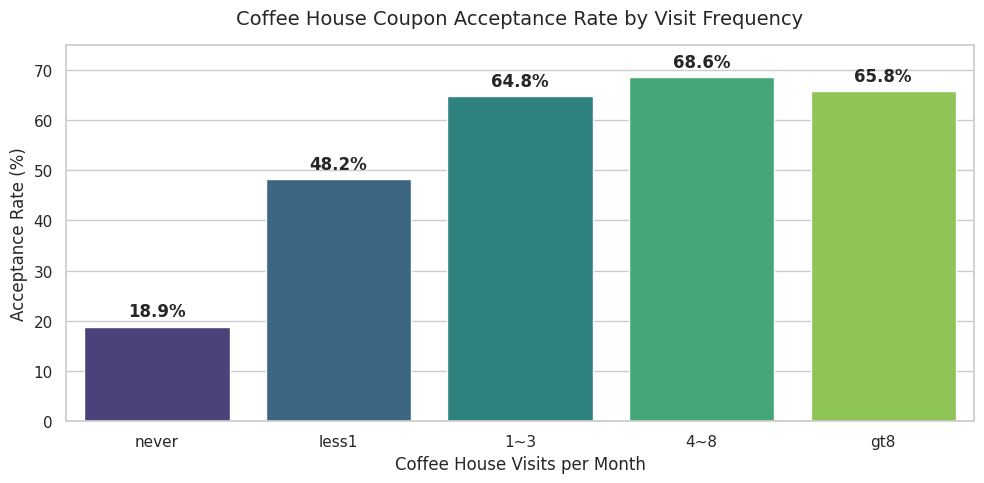

/tmp/ipykernel_3115/3748631959.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age', y='Y', data=coffee, estimator=lambda x: x.mean()*100,
/tmp/ipykernel_3115/3748631959.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, v in enumerate(coffee.groupby('age')['Y'].mean()*100):


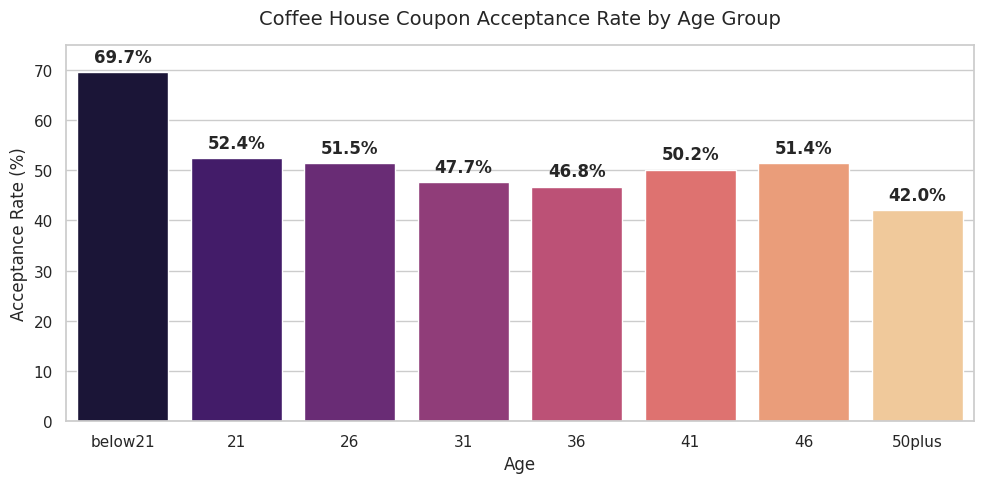

/tmp/ipykernel_3115/3748631959.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='passanger', y='Y', data=coffee, estimator=lambda x: x.mean()*100,


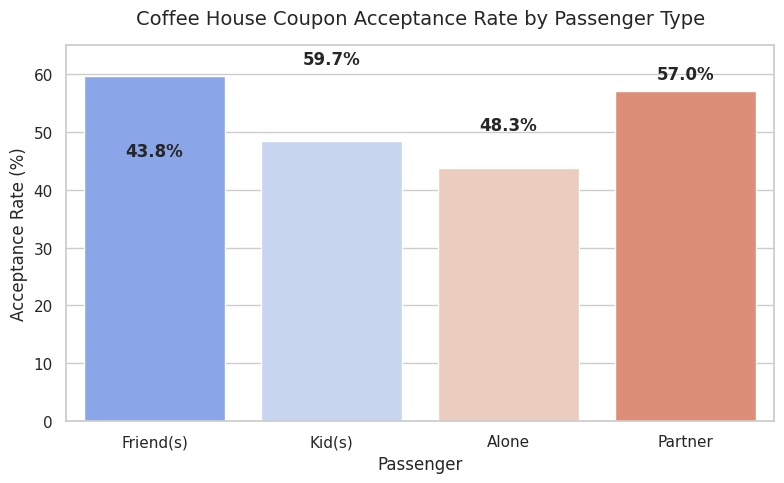

In [22]:
# Filter to Coffee House coupons only
coffee = df[df['coupon'] == 'Coffee House'].copy()

# Order categories for clean charts
freq_order = ['never', 'less1', '1~3', '4~8', 'gt8']
age_order = ['below21', '21', '26', '31', '36', '41', '46', '50plus']

coffee['CoffeeHouse'] = pd.Categorical(coffee['CoffeeHouse'], categories=freq_order, ordered=True)
coffee['age'] = pd.Categorical(coffee['age'], categories=age_order, ordered=True)

# ==================== CHARTS ====================

# Chart 1: Acceptance by Coffee House visit frequency
plt.figure(figsize=(10, 5))
sns.barplot(x='CoffeeHouse', y='Y', data=coffee, estimator=lambda x: x.mean()*100,
            errorbar=None, palette='viridis')
plt.title('Coffee House Coupon Acceptance Rate by Visit Frequency', fontsize=14, pad=15)
plt.ylabel('Acceptance Rate (%)')
plt.xlabel('Coffee House Visits per Month')
plt.ylim(0, 75)
for i, v in enumerate(coffee.groupby('CoffeeHouse')['Y'].mean()*100):
    plt.text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Chart 2: Acceptance by Age Group
plt.figure(figsize=(10, 5))
sns.barplot(x='age', y='Y', data=coffee, estimator=lambda x: x.mean()*100,
            errorbar=None, palette='magma')
plt.title('Coffee House Coupon Acceptance Rate by Age Group', fontsize=14, pad=15)
plt.ylabel('Acceptance Rate (%)')
plt.xlabel('Age')
plt.ylim(0, 75)
for i, v in enumerate(coffee.groupby('age')['Y'].mean()*100):
    plt.text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Chart 3: Acceptance by Passenger Type
plt.figure(figsize=(8, 5))
sns.barplot(x='passanger', y='Y', data=coffee, estimator=lambda x: x.mean()*100,
            errorbar=None, palette='coolwarm')
plt.title('Coffee House Coupon Acceptance Rate by Passenger Type', fontsize=14, pad=15)
plt.ylabel('Acceptance Rate (%)')
plt.xlabel('Passenger')
plt.ylim(0, 65)
for i, v in enumerate(coffee.groupby('passanger')['Y'].mean()*100):
    plt.text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


Will the customer accept the coupon?

Who is most likely to accept a Coffee House coupon?
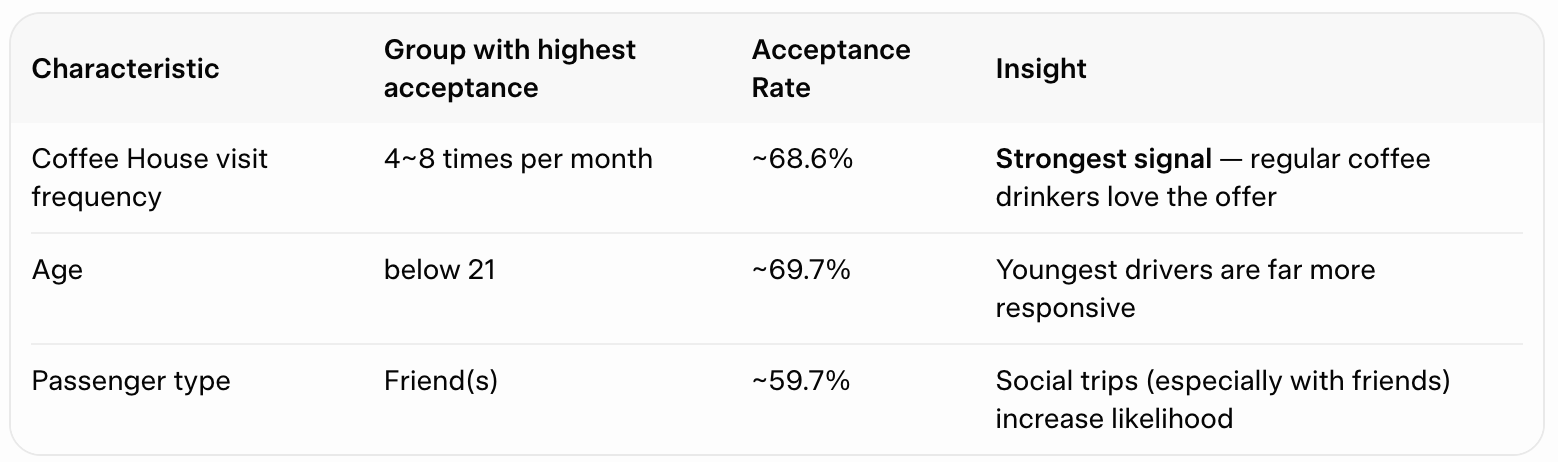

Hypothesis:
Yes — the customer is very likely to accept the Coffee House coupon if they:

Already go to coffee houses 4+ times a month, and

Are young (especially under 21), and

Are traveling with friends (or a partner) rather than alone or with kids.

The patterns are quite strong and intuitive — relevance (habit), age (openness to deals), and social context matter a lot for this coupon type.


/tmp/ipykernel_3115/1453121679.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='CoffeeHouse', y='Y', data=coffee,


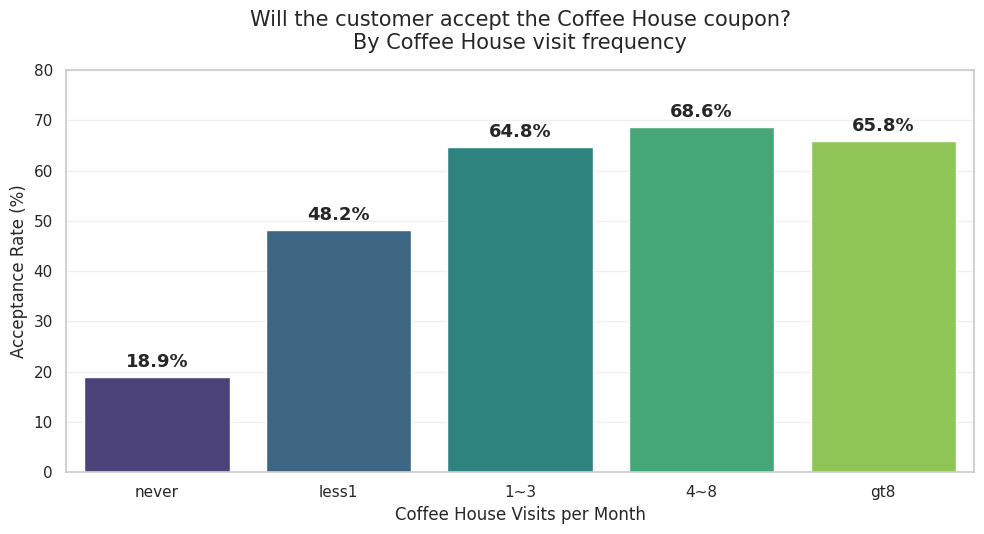

/tmp/ipykernel_3115/1453121679.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age', y='Y', data=coffee,


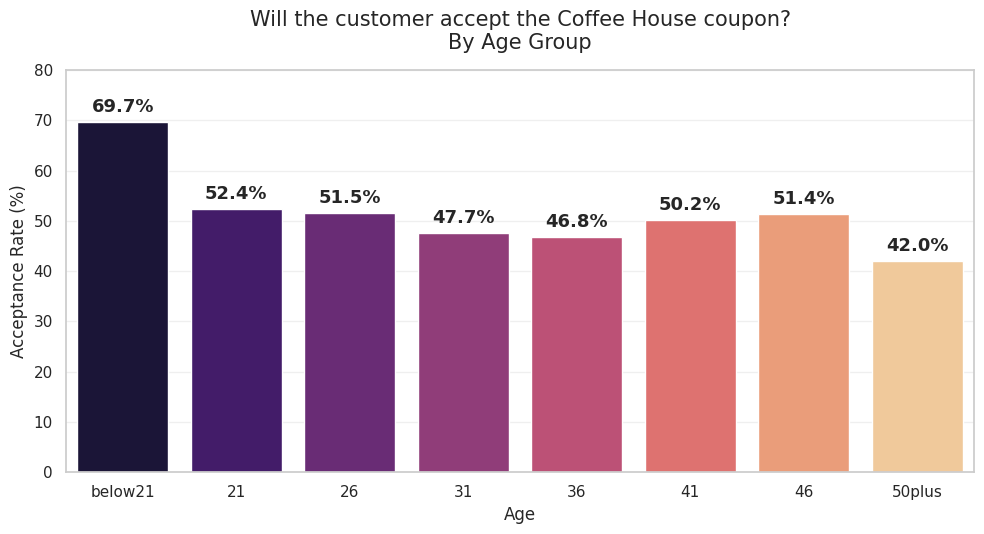

/tmp/ipykernel_3115/1453121679.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='passanger', y='Y', data=coffee,


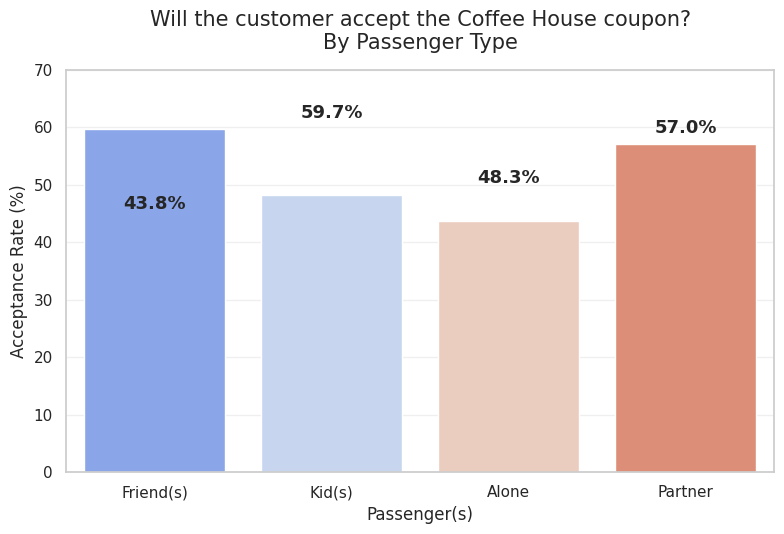

In [23]:
# Filter to Coffee House coupons — most common type after cheap restaurants
coffee = df[df['coupon'] == 'Coffee House'].copy()

# Prepare ordered categories for better chart ordering
freq_order = ['never', 'less1', '1~3', '4~8', 'gt8']
age_order  = ['below21', '21', '26', '31', '36', '41', '46', '50plus']

coffee['CoffeeHouse'] = pd.Categorical(coffee['CoffeeHouse'], categories=freq_order, ordered=True)
coffee['age']         = pd.Categorical(coffee['age'], categories=age_order, ordered=True)

# ───────────────────────────────────────────────
#   Three key charts showing who is most likely
#   to accept a Coffee House coupon
# ───────────────────────────────────────────────

# Chart 1: Acceptance by how often they visit coffee houses
plt.figure(figsize=(10, 5.5))
sns.barplot(x='CoffeeHouse', y='Y', data=coffee,
            estimator=lambda x: x.mean()*100, errorbar=None, palette='viridis')
plt.title('Will the customer accept the Coffee House coupon?\nBy Coffee House visit frequency', fontsize=15, pad=15)
plt.ylabel('Acceptance Rate (%)', fontsize=12)
plt.xlabel('Coffee House Visits per Month', fontsize=12)
plt.ylim(0, 80)
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(coffee.groupby('CoffeeHouse', observed=True)['Y'].mean()*100):
    plt.text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Chart 2: Acceptance by age group
plt.figure(figsize=(10, 5.5))
sns.barplot(x='age', y='Y', data=coffee,
            estimator=lambda x: x.mean()*100, errorbar=None, palette='magma')
plt.title('Will the customer accept the Coffee House coupon?\nBy Age Group', fontsize=15, pad=15)
plt.ylabel('Acceptance Rate (%)', fontsize=12)
plt.xlabel('Age', fontsize=12)
plt.ylim(0, 80)
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(coffee.groupby('age', observed=True)['Y'].mean()*100):
    plt.text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Chart 3: Acceptance by who is in the car (passenger type)
plt.figure(figsize=(8, 5.5))
sns.barplot(x='passanger', y='Y', data=coffee,
            estimator=lambda x: x.mean()*100, errorbar=None, palette='coolwarm')
plt.title('Will the customer accept the Coffee House coupon?\nBy Passenger Type', fontsize=15, pad=15)
plt.ylabel('Acceptance Rate (%)', fontsize=12)
plt.xlabel('Passenger(s)', fontsize=12)
plt.ylim(0, 70)
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(coffee.groupby('passanger')['Y'].mean()*100):
    plt.text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

